In [1]:
# ============================================================
# Project 1: The Care Home Crisis
# Analyst: Adebowale Adebare
# Data Source: Care Quality Commission (cqc.org.uk)
# Date: August 2026
# ============================================================

# Import all required libraries

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')



In [2]:
# ── STEP 1: LOAD RAW DATA ─────────────────────
# Source: CQC Care Directory with Filters (04 August 2026)
# Downloaded from: cqc.org.uk/about-us/transparency/using-cqc-data
# Contains all health and social care locations registered in England
# Raw file: 57,009 locations across 122 columns

df_cqc = pd.read_excel(
    r"C:\Users\adeba\OneDrive\Documents\Portfolio\Project1_CQC\04_August_2026_HSCA_Active_Locations.ods",
    engine='odf',
    sheet_name='HSCA_Active_Locations'
)

print(df_cqc.shape)
print(df_cqc.columns.tolist())
df_cqc.head()

(57009, 122)
['Location ID', 'Location HSCA start date', 'Dormant (Y/N)', 'Care home?', 'Location Name', 'Location ODS Code', 'Location Telephone Number', 'Registered manager', 'Location Web Address', 'Care homes beds', 'Location Type/Sector', 'Location Inspection Directorate', 'Location Primary Inspection Category', 'Location Latest Overall Rating', 'Publication Date', 'Inherited Rating (Y/N)', 'Location Region', 'Location NHS Region', 'Location Local Authority', 'Location ONSPD CCG Code', 'Location ONSPD CCG', 'Location Commissioning CCG Code', 'Location Commissioning CCG', 'Location Street Address', 'Location Address Line 2', 'Location City', 'Location County', 'Location Postal Code', 'Location PAF ID', 'Location UPRN ID', 'Location Latitude', 'Location Longitude', 'Location Parliamentary Constituency', 'Brand ID', 'Brand Name', 'Provider Companies House Number', 'Provider Charity Number', 'Provider ID', 'Provider Name', 'Provider HSCA start date', 'Provider Type/Sector', 'Provider 

,Location ID,Location HSCA start date,Dormant (Y/N),Care home?,Location Name,Location ODS Code,Location Telephone Number,Registered manager,Location Web Address,Care homes beds,...,Service user band - Older People,Service user band - People detained under the Mental Health Act,Service user band - People who misuse drugs and alcohol,Service user band - People with an eating disorder,Service user band - Physical Disability,Service user band - Sensory Impairment,Service user band - Whole Population,Service user band - Younger Adults,Location Dual Registered,Primary ID (Dual registration locations)
0,1-10000302982,2020-12-11,N,Y,Henley House,VNH4N,NaN,*,www.greensleeves.org.uk/care-homes/henley-hous...,66.0,...,Y,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN
1,1-10000697432,2021-01-07,N,N,Vara Dental Practice,V03134,2.085522e+09,"Vara, Jagjivan",www.varadentalpractice.co.uk,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,Y,NaN,NaN,NaN
2,1-10000792582,2020-12-09,N,N,Orchids Care,VNH4P,1.302571e+09,"Robson, Sarah",www.orchids-care.co.uk,0.0,...,Y,NaN,NaN,NaN,Y,NaN,NaN,Y,NaN,NaN
3,1-10000812939,2020-12-18,N,Y,Charlotte House,VNH4Q,1.516431e+09,"Evans, Philip",NaN,103.0,...,Y,NaN,NaN,NaN,Y,Y,NaN,NaN,NaN,NaN
4,1-10000813008,2020-12-18,N,Y,Regency Care Centre,VNH4R,1.617962e+09,"Birkett, Nichola",NaN,60.0,...,Y,NaN,NaN,NaN,Y,NaN,NaN,NaN,NaN,NaN


In [3]:
# ── STEP 2: SELECT RELEVANT COLUMNS ─────────────────────────
# The raw file contains 122 columns — most are irrelevant to care home analysis
# We retain only 16 columns directly relevant to our business questions

columns_needed = [
    'Location ID',
    'Location Name',
    'Location Region',
    'Location Local Authority',
    'Location Latest Overall Rating',
    'Care home?',
    'Care homes beds',
    'Dormant (Y/N)',
    'Location Primary Inspection Category',
    'Service type - Care home service with nursing',
    'Service type - Care home service without nursing',
    'Service user band - Older People',
    'Service user band - Dementia',
    'Publication Date',
    'Provider Name',
    'Location Postal Code'
]

df_care = df_cqc[columns_needed].copy()
print(df_care.shape)
df_care.head()

(57009, 16)


,Location ID,Location Name,Location Region,Location Local Authority,Location Latest Overall Rating,Care home?,Care homes beds,Dormant (Y/N),Location Primary Inspection Category,Service type - Care home service with nursing,Service type - Care home service without nursing,Service user band - Older People,Service user band - Dementia,Publication Date,Provider Name,Location Postal Code
0,1-10000302982,Henley House,East of England,Suffolk,Good,Y,66.0,N,Residential social care,NaN,Y,Y,Y,2022-04-20,Greensleeves Homes Trust,IP1 6TB
1,1-10000697432,Vara Dental Practice,London,Newham,NaN,N,0.0,N,Dentists,NaN,NaN,NaN,NaN,NaT,Vara Dental,E12 6SA
2,1-10000792582,Orchids Care,Yorkshire and The Humber,Doncaster,Good,N,0.0,N,Community based adult social care services,NaN,NaN,Y,Y,2022-07-15,Orchids Care Limited,DN4 9LX
3,1-10000812939,Charlotte House,North West,Wirral,Good,Y,103.0,N,Residential social care,Y,NaN,Y,Y,2023-04-04,Lovett Care Limited,CH63 3DZ
4,1-10000813008,Regency Care Centre,North West,Bury,Good,Y,60.0,N,Residential social care,Y,NaN,Y,Y,2021-07-15,Lovett Care Limited,M45 7SG


In [4]:
# ── STEP 3: FILTER TO ACTIVE CARE HOMES ONLY ─────────────────
# The raw data includes GP surgeries, dentists, hospitals,
# domiciliary care agencies and many other service types
# We filter to care homes only (Care home? == Y)
# and remove dormant locations (registered but not operating)

df_care_homes = df_care[
    (df_care['Care home?'] == 'Y') &
    (df_care['Dormant (Y/N)'] != 'Y')
]

print(df_care_homes.shape)
print(df_care_homes['Location Latest Overall Rating'].value_counts())

(14789, 16)
Location Latest Overall Rating
Good                    10615
Requires improvement     2255
Outstanding               615
Inadequate                100
Not Rated                  83
Name: count, dtype: int64


In [5]:
# ── STEP 4: INVESTIGATE DATA QUALITY ─────────────────────────
# Before cleaning, we check null values across all columns
# Key concern: 1,121 homes have no CQC rating
# This is expected — newly registered homes await their first inspection
# These must be excluded from any rating comparison analysis

print(df_care_homes.isnull().sum())

# Check West Sussex specifically
west_sussex = df_care_homes[
    df_care_homes['Location Local Authority'] == 'West Sussex'
]
print(f"\nWest Sussex care homes: {west_sussex.shape[0]}")
print(west_sussex['Location Latest Overall Rating'].value_counts())

Location ID                                             0
Location Name                                           0
Location Region                                         0
Location Local Authority                                2
Location Latest Overall Rating                       1121
Care home?                                              0
Care homes beds                                         1
Dormant (Y/N)                                           0
Location Primary Inspection Category                    0
Service type - Care home service with nursing       10317
Service type - Care home service without nursing     4451
Service user band - Older People                     3360
Service user band - Dementia                         6406
Publication Date                                     1204
Provider Name                                           0
Location Postal Code                                    0
dtype: int64

West Sussex care homes: 339
Location Latest Overall Rating

In [6]:
# ── STEP 5: REMOVE UNRATED HOMES ─────────────────────────────
# Homes with no rating have not yet been inspected by CQC
# Including them would distort rating distribution analysis
# We also remove 'Not Rated' category (services with multiple types
# that no longer receive a single location-level rating under new CQC approach)
# Decision: Only analyse homes with a definitive rating
df_rated = df_care_homes[
    df_care_homes['Location Latest Overall Rating'].notna() &
    (df_care_homes['Location Latest Overall Rating'] != 'Not Rated')
]

print(f"Rated care homes: {df_rated.shape[0]}")
print(df_rated['Location Latest Overall Rating'].value_counts())

Rated care homes: 13585
Location Latest Overall Rating
Good                    10615
Requires improvement     2255
Outstanding               615
Inadequate                100
Name: count, dtype: int64


In [7]:
# Define colours for each rating
#colors = {
 #   'Outstanding': '#2ecc71',
#    'Good': '#3498db', 
#    'Requires improvement': '#e67e22',
#    'Inadequate': '#e74c3c'
#}

#rating_counts = df_rated['Location Latest Overall Rating'].value_counts()
#rating_colors = [colors[r] for r in rating_counts.index]

#plt.figure(figsize=(10, 6))
#bars = plt.bar(rating_counts.index, rating_counts.values, color=rating_colors)

# Add counts on top of bars
#for bar, count in zip(bars, rating_counts.values):
#    plt.text(bar.get_x() + bar.get_width()/2, 
#             bar.get_height() + 50,
#             f'{count:,}', ha='center', fontsize=10)

#plt.title('CQC Care Home Ratings — England (August 2026)', 
#          fontsize=14, fontweight='bold')
#plt.ylabel('Number of Care Homes')
#plt.xlabel('CQC Rating')
#plt.tight_layout()
#plt.savefig('national_ratings.png', dpi=150)
#plt.show()

In [8]:
# ── STEP 6: EXPORT CLEAN DATASET FOR SQL ANALYSIS ────────────
# The cleaned dataset (13,585 rated care homes) is exported to CSV
# This file will be imported into MySQL Workbench as table: cqc_care_homes
# SQL analysis will answer 7 business questions about care home performance
os.makedirs(r"C:\Users\adeba\OneDrive\Documents\Portfolio\Project1_CQC", exist_ok=True)

df_rated.to_csv(r"C:\Users\adeba\OneDrive\Documents\Portfolio\Project1_CQC\cqc_rated_carehomes.csv", index=False)

print("Saved successfully!")

# ── DATA INTEGRITY NOTE ───────────────────────────────────────
# Note: 13,585 rows in Python → 13,584 rows in MySQL
# Difference of 1 row attributed to a care home name containing
# special characters (em dash or curly apostrophe) that caused
# a MySQL CSV import encoding issue
# Impact: Negligible — 1 row out of 13,585 (0.007%)
# This does not materially affect any analysis findings

Saved successfully!


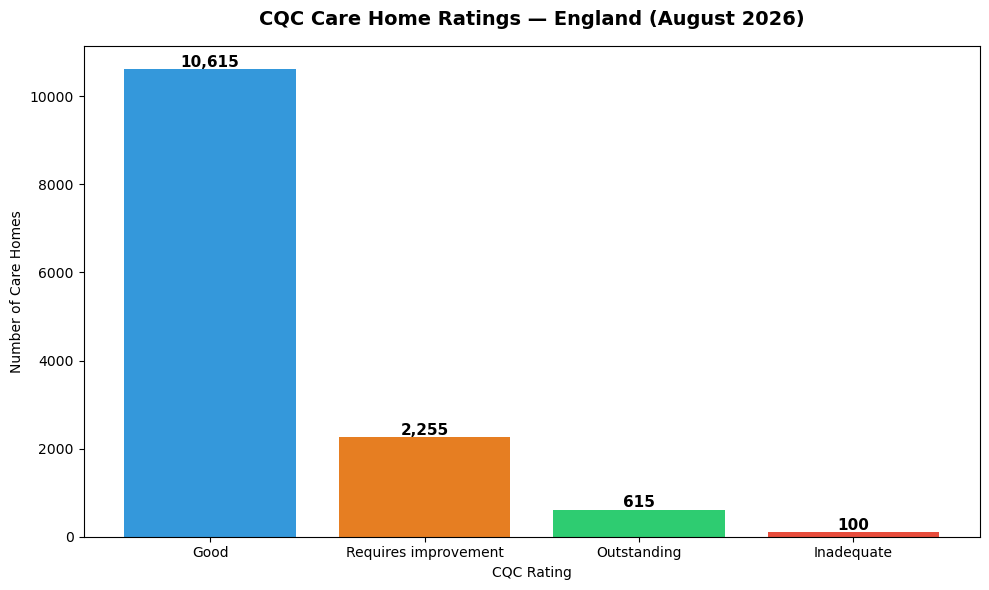

In [9]:


##Chart 1 — National CQC Rating Distribution
colors = ['#3498db', '#e67e22', '#2ecc71', '#e74c3c']
ratings = ['Good', 'Requires improvement', 'Outstanding', 'Inadequate']
counts = [10615, 2255, 615, 100]

plt.figure(figsize=(10, 6))
bars = plt.bar(ratings, counts, color=colors)

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,
             f'{count:,}', ha='center', fontsize=11, fontweight='bold')

plt.title('CQC Care Home Ratings — England (August 2026)',
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Number of Care Homes')
plt.xlabel('CQC Rating')
plt.tight_layout()
plt.savefig(r'C:\Users\adeba\OneDrive\Documents\Portfolio\Project1_CQC\chart1_national_ratings.png', dpi=150)
plt.show()


#rating_counts = df_rated['Location Latest Overall Rating'].value_counts()

#plt.figure(figsize=(10, 6))
#bars = plt.bar(rating_counts.index, rating_counts.values, 
#               color=['#3498db', '#e67e22', '#2ecc71', '#e74c3c'])

#for bar, count in zip(bars, rating_counts.values):
#    plt.text(bar.get_x() + bar.get_width()/2,
#             bar.get_height() + 50,
#             f'{count:,}', ha='center', fontsize=11, fontweight='bold')

#plt.title('CQC Care Home Ratings — England (August 2026)',
#          fontsize=14, fontweight='bold')
#plt.ylabel('Number of Care Homes')
#plt.tight_layout()
#plt.savefig(r'C:\Users\adeba\OneDrive\Documents\Portfolio\Project1_CQC\chart1_national_ratings.png', dpi=150)
#plt.show()

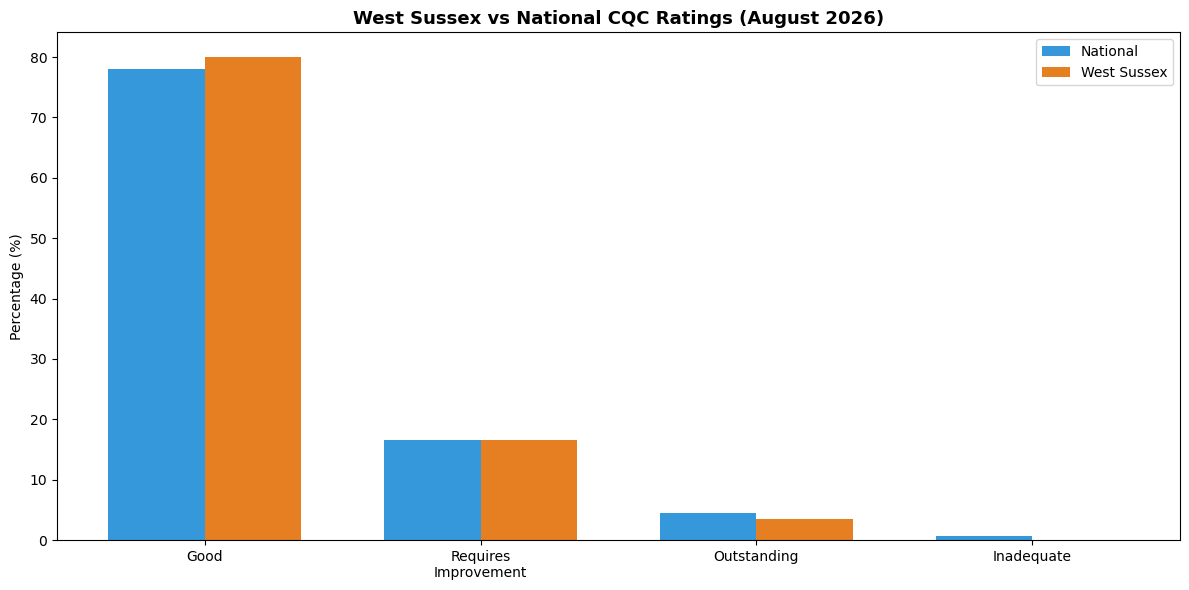

In [10]:
import numpy as np

# Data from SQL Q3
ratings = ['Good', 'Requires\nImprovement', 'Outstanding', 'Inadequate']
national_pct = [78.1, 16.6, 4.5, 0.7]
west_sussex_pct = [80.1, 16.5, 3.5, 0.0]

x = np.arange(len(ratings))
width = 0.35

plt.figure(figsize=(12, 6))
bars1 = plt.bar(x - width/2, national_pct, width, 
                label='National', color='#3498db')
bars2 = plt.bar(x + width/2, west_sussex_pct, width, 
                label='West Sussex', color='#e67e22')

plt.title('West Sussex vs National CQC Ratings (August 2026)',
          fontsize=13, fontweight='bold')
plt.ylabel('Percentage (%)')
plt.xticks(x, ratings)
plt.legend()
plt.tight_layout()
plt.savefig(r'C:\Users\adeba\OneDrive\Documents\Portfolio\Project1_CQC\chart2_westsussex_vs_national.png', dpi=150)
plt.show()

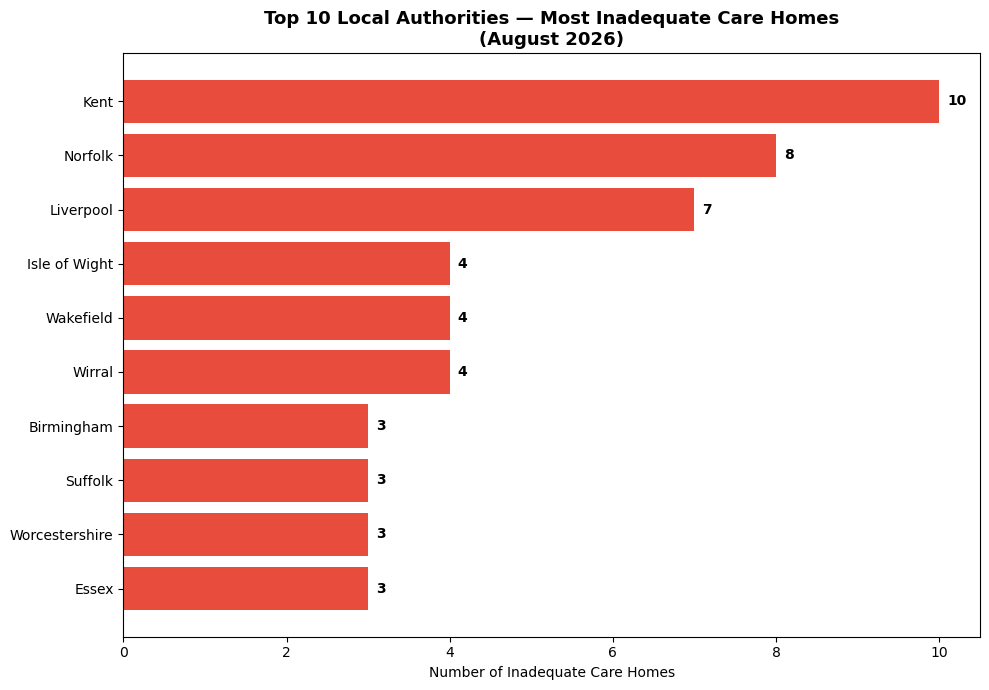

In [11]:
# Data from SQL Q4
local_authorities = [
    'Kent', 'Norfolk', 'Liverpool', 'Isle of Wight', 
    'Wakefield', 'Wirral', 'Birmingham', 
    'Suffolk', 'Worcestershire', 'Essex'
]
inadequate_count = [10, 8, 7, 4, 4, 4, 3, 3, 3, 3]

plt.figure(figsize=(10, 7))
bars = plt.barh(local_authorities, inadequate_count, color='#e74c3c')

for bar, count in zip(bars, inadequate_count):
    plt.text(bar.get_width() + 0.1,
             bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=10, fontweight='bold')

plt.title('Top 10 Local Authorities — Most Inadequate Care Homes\n(August 2026)',
          fontsize=13, fontweight='bold')
plt.xlabel('Number of Inadequate Care Homes')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(r'C:\Users\adeba\OneDrive\Documents\Portfolio\Project1_CQC\chart3_inadequate_authorities.png', dpi=150)
plt.show()

# Project 1 — The Care Home Crisis
## Analysing CQC Care Home Ratings Across England

### Overview
This project analyses 13,585 rated care homes across England using real data 
from the Care Quality Commission (CQC), published August 2026. The analysis 
investigates rating distributions nationally, regionally and locally — with a 
specific focus on West Sussex where I work as a care professional.

### Tools Used
- Python (Pandas) — Data loading, cleaning and preparation
- MySQL — Business question analysis
- Matplotlib — Data visualisation

### Data Source
Care Quality Commission — Care Directory with Filters (August 2026)
cqc.org.uk/about-us/transparency/using-cqc-data

### Data Journey
| Stage | Count |
|---|---|
| Raw CQC locations | 57,009 |
| Active care homes only | 14,789 |
| Rated care homes (final) | 13,585 |

### Key Findings

**1. Only 4.5% of care homes achieve Outstanding nationally**
The vast majority (78.1%) are rated Good — suggesting the sector 
performs adequately but rarely exceptionally.

**2. East Midlands leads for Outstanding ratings (6.5%)**
Despite London's size and resources, it ranks lowest for Outstanding 
proportion at just 2.6% — a significant regional disparity.

**3. West Sussex performs above national average for Good ratings (80.1% vs 78.1%)**
Notably, West Sussex has zero Inadequate care homes — better than the 
national average of 0.7%.

**4. Kent accounts for 10% of all Inadequate homes nationally**
With 10 out of 100 Inadequate homes concentrated in one county — 
this represents a significant local challenge requiring targeted intervention.

**5. Residential homes outnumber nursing homes 2:1**
9,530 residential-only homes vs 4,035 nursing-only homes — 
yet nursing homes achieve a higher Outstanding rate (6.4% vs 4.4%).

### Business Relevance
These findings directly inform GoldCare Connect's market strategy:
- Target regions with high Requires Improvement rates — these homes 
  need better workforce management most urgently
- West Sussex represents a strong starting market — above average 
  performance suggests professional, quality-focused operators

### Files
- `Project1_CQC_Preparation.ipynb` — Data cleaning and visualisation
- `Project1_CQC_Analysis.sql` — SQL business questions
- `cqc_rated_carehomes.csv` — Cleaned dataset (13,585 rows)